The contents of this notebook were created with assistance from Claude generative AI.

# 03 · Geography — who feels how, and where

Three nested views of the same question:

1. **Geo tiers** (Manhattan core / outer boroughs / citywide / NJ / CT / Hudson-LI
   / activist) — the robust, large-n comparison.
2. **CBD vs Non-CBD Manhattan** — below vs above 60th St. ⚠️ CBD side is thin
   (≈`r/eastvillage` only); read as suggestive.
3. **Individual Manhattan subreddits** — UES / UWS / Harlem / EastVillage /
   manhattan, each with CIs and n-suppression.

Then a **pre/post-launch** comparison per tier with two-proportion tests.

In [1]:
import sys; sys.path.append(".")        # so config / analysis_utils import on Deepnote too
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import config as C
import analysis_utils as A
A.apply_style()
pd.set_option("display.width", 120)

In [2]:
sh = A.add_geo(A.load_rollup("stance_hourly"))

def net_by(group_col, grain="monthly", subset=None, min_n=None):
    """Net index over time within each value of group_col."""
    df = sh if subset is None else sh[subset]
    agg = A.aggregate(df, grain, by=(group_col,), stance_col="stance")
    wide = A.stance_shares(agg, index_cols=["period", group_col]).sort_values("period")
    lo, hi = A.net_ci(wide.share_pro, wide.share_anti, wide.n_total)
    wide["net_lo"], wide["net_hi"] = lo, hi
    if min_n: wide = wide[wide.n_total >= min_n]
    return wide

### 1 · Net stance by geo tier (monthly small-multiples)

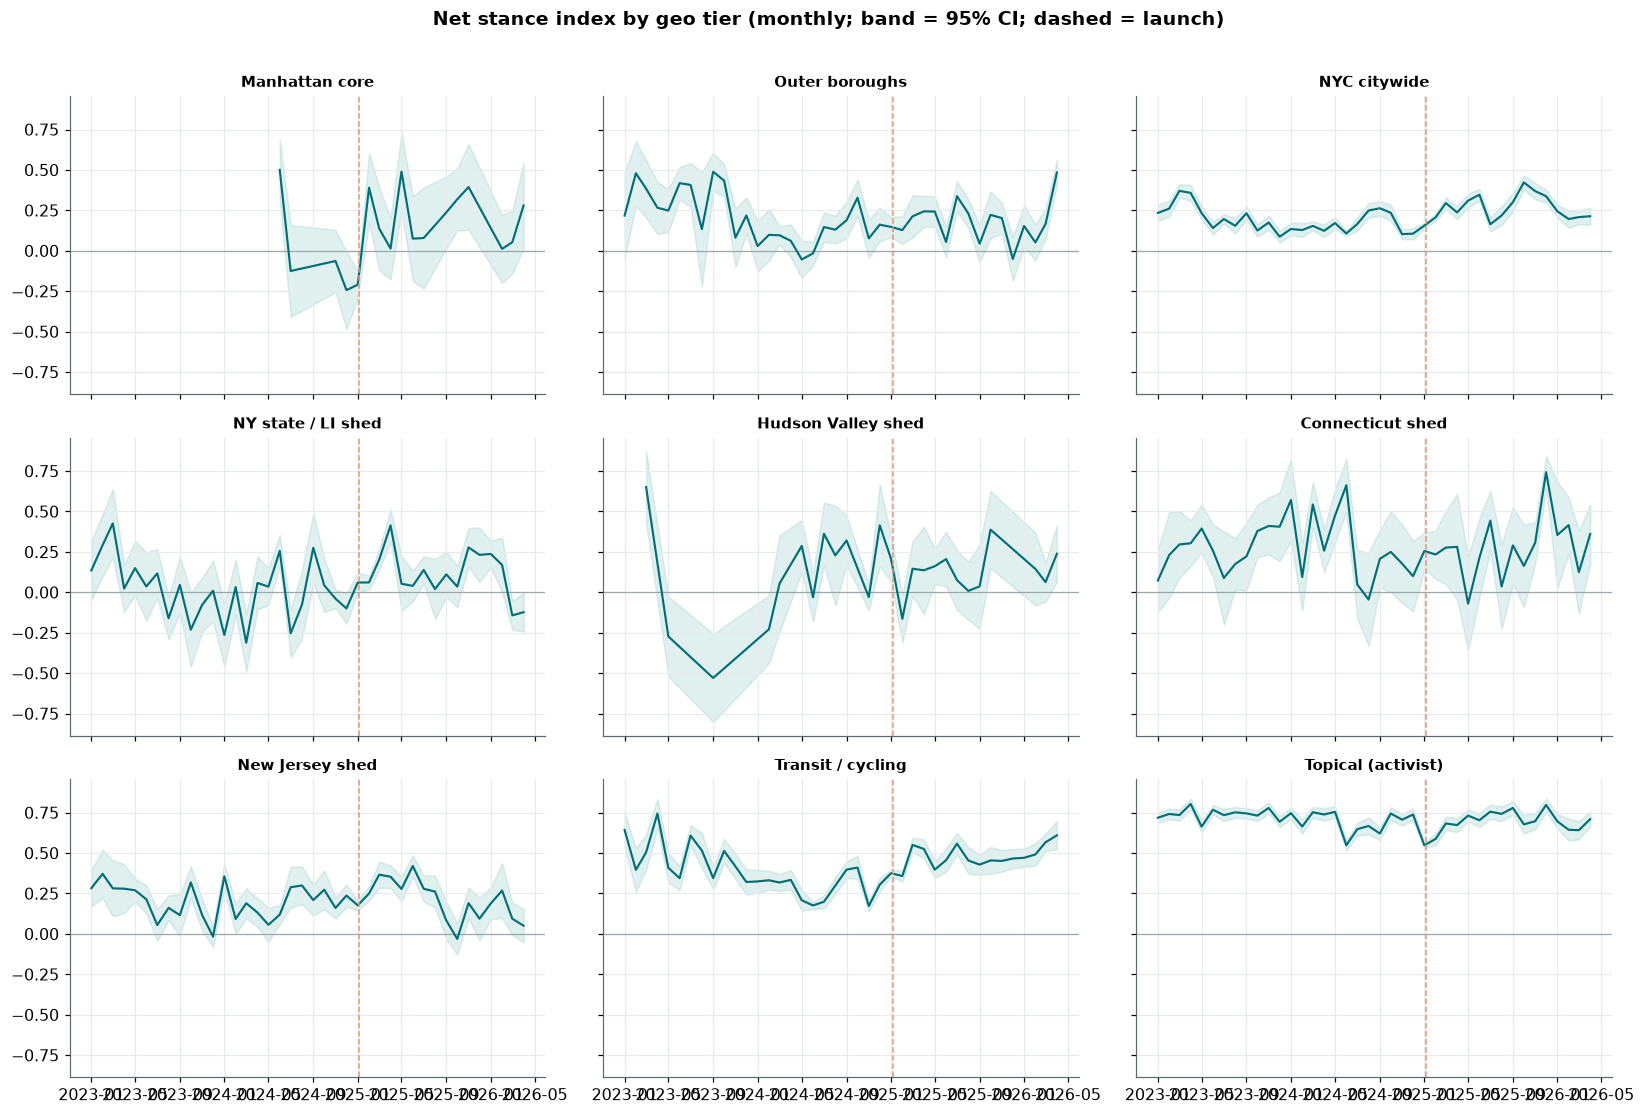

In [3]:
gt = net_by("geo_tier", min_n=C.MIN_N)
tiers = [t for t in C.GEO_TIER_ORDER if t in gt.geo_tier.unique()]
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)
for ax, tier in zip(axes.ravel(), tiers):
    w = gt[gt.geo_tier==tier]
    ax.axhline(0, color="#9AA7AB", lw=0.8)
    ax.fill_between(w.period, w.net_lo, w.net_hi, color=C.PALETTE["teal"], alpha=0.25)
    ax.plot(w.period, w.net, color=C.PALETTE["deep_teal"], lw=1.4)
    ax.axvline(pd.Timestamp("2025-01-05"), color=C.PALETTE["terracotta"], ls="--", lw=1)
    ax.set_title(tier, fontsize=10)
for ax in axes.ravel()[len(tiers):]: ax.axis("off")
fig.suptitle("Net stance index by geo tier (monthly; band = 95% CI; dashed = launch)", y=1.01, fontweight="bold")
plt.tight_layout(); plt.show()

### 2 · CBD vs Non-CBD Manhattan  ⚠️ thin data — wide CIs on purpose

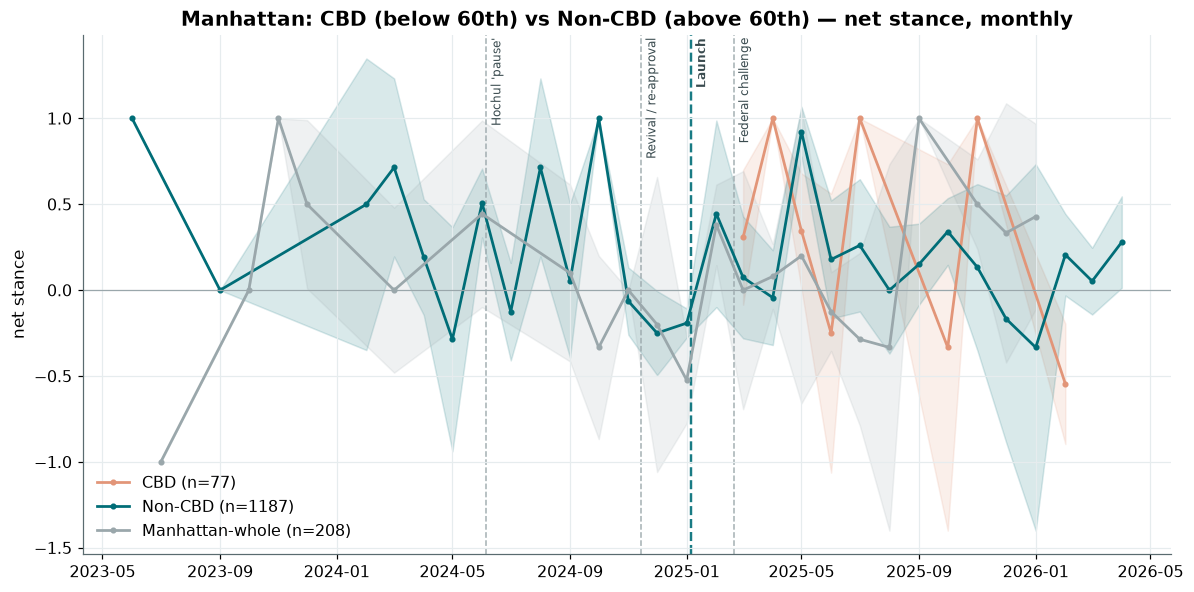

Total items per zone:
 cbd_zone
CBD                 136
Manhattan-whole     288
Non-CBD            2157
Name: n, dtype: int64


In [4]:
man = sh[sh.cbd_zone.notna()]
cz = net_by("cbd_zone", subset=sh.cbd_zone.notna())
fig, ax = plt.subplots()
colors = {"CBD":C.PALETTE["terracotta"],"Non-CBD":C.PALETTE["deep_teal"],"Manhattan-whole":"#9AA7AB"}
for zone in C.CBD_ZONE_ORDER:
    w = cz[cz.cbd_zone==zone]
    if w.empty: continue
    ax.fill_between(w.period, w.net_lo, w.net_hi, color=colors[zone], alpha=0.15)
    ax.plot(w.period, w.net, color=colors[zone], lw=1.8, marker="o", ms=3, label=f"{zone} (n={int(w.n_total.sum())})")
ax.axhline(0, color="#9AA7AB", lw=0.8); ax.set_ylabel("net stance")
ax.set_title("Manhattan: CBD (below 60th) vs Non-CBD (above 60th) — net stance, monthly"); ax.legend()
A.annotate_events(ax)
plt.tight_layout(); plt.show()
print("Total items per zone:\n", man.assign(n=man.n if "n" in man else 1).groupby("cbd_zone")["n"].sum())

### 3 · Individual Manhattan subreddits (n-suppressed)

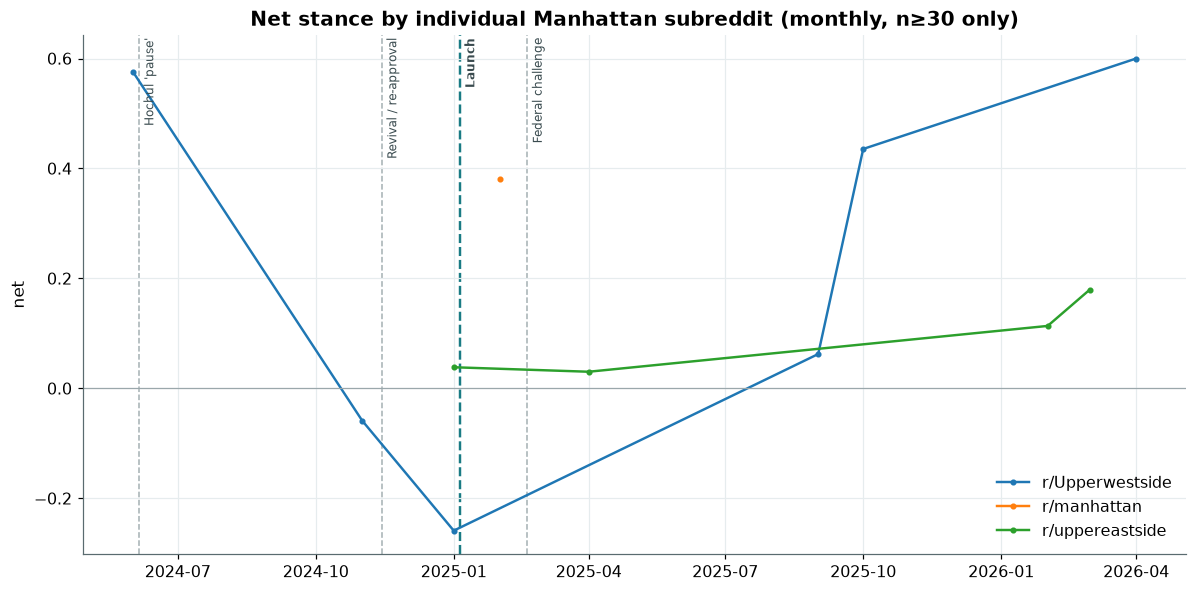

Note: months with < 30 on-topic items are dropped — that's why lines are sparse for small subs.


In [5]:
mh_subs = ["manhattan","uppereastside","Upperwestside","Harlem","eastvillage"]
sub = sh[sh.subreddit.str.lower().isin([s.lower() for s in mh_subs])]
sw = net_by("subreddit", subset=sh.subreddit.str.lower().isin([s.lower() for s in mh_subs]), min_n=C.MIN_N)
fig, ax = plt.subplots()
for i, s in enumerate(sorted(sw.subreddit.unique())):
    w = sw[sw.subreddit==s]
    ax.plot(w.period, w.net, lw=1.6, marker="o", ms=3, label=f"r/{s}")
ax.axhline(0, color="#9AA7AB", lw=0.8)
ax.set_title(f"Net stance by individual Manhattan subreddit (monthly, n≥{C.MIN_N} only)"); ax.set_ylabel("net"); ax.legend()
A.annotate_events(ax)
plt.tight_layout(); plt.show()
print("Note: months with <", C.MIN_N, "on-topic items are dropped — that's why lines are sparse for small subs.")

### 4 · Pre vs post launch, per tier — with significance tests

For each tier we compare on-topic stance composition in the 180 days before vs
after launch (two-proportion z-test on pro-share and on anti-share), with
**Benjamini–Hochberg** correction across tiers.

In [6]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
launch = pd.Timestamp("2025-01-05"); win = pd.Timedelta(days=180)
sh2 = sh.copy()
sh2["win"] = np.where((sh2.et_date>=launch-win)&(sh2.et_date<launch), "pre",
              np.where((sh2.et_date>=launch)&(sh2.et_date<launch+win), "post", None))
seg = sh2[sh2.win.notna() & sh2.stance.isin(["anti","neutral","pro"])]
rows=[]
for tier, g in seg.groupby("geo_tier"):
    piv = g.pivot_table(index="win", columns="stance", values="n", aggfunc="sum", fill_value=0)
    if not {"pre","post"}.issubset(piv.index): continue
    n_pre, n_post = piv.loc["pre"].sum(), piv.loc["post"].sum()
    net_pre  = (piv.loc["pre","pro"]-piv.loc["pre","anti"])/n_pre
    net_post = (piv.loc["post","pro"]-piv.loc["post","anti"])/n_post
    z,p = proportions_ztest([piv.loc["post","pro"],piv.loc["pre","pro"]],[n_post,n_pre])
    rows.append([tier,int(n_pre),int(n_post),net_pre,net_post,net_post-net_pre,p])
res = pd.DataFrame(rows, columns=["geo_tier","n_pre","n_post","net_pre","net_post","delta","p_pro"])
res["p_adj"] = multipletests(res.p_pro, method="fdr_bh")[1]
res = res.sort_values("delta")
res.round(3)

,geo_tier,n_pre,n_post,net_pre,net_post,delta,p_pro,p_adj
7,Topical (activist),7307,10538,0.690,0.611,-0.079,0.000,0.000
1,Hudson Valley shed,827,844,0.099,0.120,0.021,0.541,0.541
5,New Jersey shed,2582,6663,0.221,0.258,0.038,0.293,0.377
6,Outer boroughs,1953,2585,0.130,0.183,0.053,0.488,0.541
4,NYC citywide,14020,22677,0.157,0.227,0.070,0.013,0.023
0,Connecticut shed,435,641,0.140,0.229,0.089,0.148,0.222
2,Manhattan core,253,582,-0.138,0.002,0.140,0.010,0.022
8,Transit / cycling,9396,11891,0.262,0.416,0.153,0.000,0.000
3,NY state / LI shed,1977,4227,-0.054,0.109,0.163,0.000,0.000


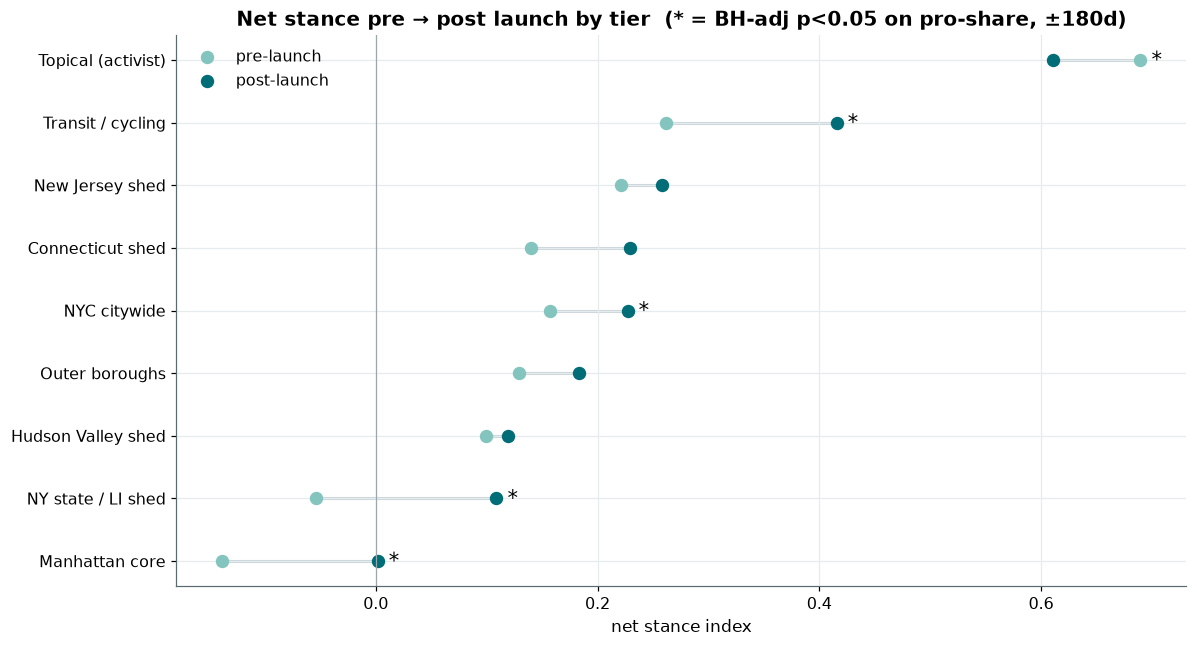

In [7]:
# Dumbbell: net stance pre -> post per tier
r = res.sort_values("net_post")
fig, ax = plt.subplots(figsize=(11,6))
y = np.arange(len(r))
ax.hlines(y, r.net_pre, r.net_post, color="#C9D6DA", lw=2, zorder=1)
ax.scatter(r.net_pre, y, color=C.PALETTE["teal"], s=60, label="pre-launch", zorder=2)
ax.scatter(r.net_post, y, color=C.PALETTE["deep_teal"], s=60, label="post-launch", zorder=2)
for yi,(_,row) in zip(y, r.iterrows()):
    if row.p_adj < 0.05: ax.text(max(row.net_pre,row.net_post)+0.01, yi, "*", va="center", fontsize=14)
ax.axvline(0, color="#9AA7AB", lw=0.8)
ax.set_yticks(y); ax.set_yticklabels(r.geo_tier); ax.set_xlabel("net stance index")
ax.set_title("Net stance pre → post launch by tier  (* = BH-adj p<0.05 on pro-share, ±180d)"); ax.legend()
plt.tight_layout(); plt.show()